Este netbook realizara un Análisis Exploratorio de Datos (EDA) enfocado en la caracterización estructural del dataset, la evolucion y la identificación de comportamientos relevantes para guiar procesos posteriores de preprocesamiento y construcción de modelos.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [33]:
# Configuración de visualización
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# 1. Configuración e ingesta de los datos

In [34]:
def cargar_dataframe():
    # Carga del dataset de homicidios con manejo de rutas y excepciones
    ruta = Path.cwd().parent / "data" / "raw" / "base_homicidios.csv"

    try:
        df = pd.read_csv(ruta)
        print(f"Carga exitosa del DataFrame:\n\n{df.shape[0]} filas.\n{df.shape[1]} columas")

        return df

    except FileNotFoundError:
        print(f"Error: No se encontro el archivo en {ruta.absolute()}")
        return None
    
    except Exception as e:
        print(f"Error inesperado: {e}")
        return None

df = cargar_dataframe()

Carga exitosa del DataFrame:

22092 filas.
6 columas


# 2. Inspección inicial:

El objetivo es entender que tipos de datos tenemos y detectar discrepancias inmediatas.

In [35]:
""" Vista rapida de las primeras 5 columas """
display(df.head(-5))

,iso_code,country,year,sex,age_group,homicide_rate
0,AFG,Afghanistan,2009,both,ALL,4.059550
1,AFG,Afghanistan,2010,both,ALL,3.475452
2,AFG,Afghanistan,2011,both,ALL,4.194535
3,AFG,Afghanistan,2012,both,ALL,6.374339
4,AFG,Afghanistan,2015,both,ALL,9.952186
...,...,...,...,...,...,...
22082,ZWE,Zimbabwe,2019,male,ALL,8.600883
22083,ZWE,Zimbabwe,2020,both,ALL,5.023543
22084,ZWE,Zimbabwe,2020,female,ALL,1.790027
22085,ZWE,Zimbabwe,2020,male,ALL,8.601756


In [36]:
""" Diagnostico de tipos y memoria """
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22092 entries, 0 to 22091
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   iso_code       22092 non-null  object 
 1   country        22092 non-null  object 
 2   year           22092 non-null  int64  
 3   sex            22092 non-null  object 
 4   age_group      22092 non-null  object 
 5   homicide_rate  22092 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.0+ MB


Observaciones de la inspeccion:

    - Fechas: La columna fecha se detecta como int64, no va a realizarse cambios devido a que solamente tiene el dato del año.
    - Es necesario verificar si el ID es úncio por hecho o por víctima.
    

# 3. Diagnóstico de calidad de datos

In [37]:
""" Análisis de los valores nulos """
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df)) * 100
# Creacion del DataFrame de reporte
df_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje %': nulos_pct
    })

# Filtrado y ordenamiento
reporte_errores = df_nulos[df_nulos["Nulos"] > 0].sort_values(by='Porcentaje %', ascending=False)

# Salida por pantalla
print(f"Total de registro: {len(df)}")

if not reporte_errores.empty:
    print("Columnas que requieren atención imnediata (Nulos):")
    print(reporte_errores)
else:
    print("No se detectaron valores nulos en el dataset.")

Total de registro: 22092
No se detectaron valores nulos en el dataset.


In [38]:
""" Analisis de los valores duplicados """

duplicados = df.duplicated().sum()
print(f"Registro total de los duplicados {duplicados}")

Registro total de los duplicados 0


# 4. analisis estadistico y cardinal

In [39]:
# Estadísticas de variables numéricas
display(df.describe())

,year,homicide_rate
count,22092.000000,22092.000000
mean,2013.046306,8.586870
std,7.944182,21.311232
min,1990.000000,0.000000
25%,2009.000000,0.624042
50%,2015.000000,1.749959
75%,2019.000000,6.123606
max,2023.000000,373.710962


### 4.1 Análisis de cobertura por pais

In [40]:
# Agrupamos por país para ver la cantidad de registros y el rango de años
cobertura_paises = df.groupby('country').agg(
    cantidad_registros=('year', 'count'),
    año_inicio=('year', 'min'),
    año_fin=('year', 'max')
).sort_values(by='cantidad_registros', ascending=False)

print("📊 Resumen de cobertura por País (Top 10 con más datos):")
display(cobertura_paises.head(10))

print(f"\n💡 Nota: Hay {len(cobertura_paises)} países en total.")

📊 Resumen de cobertura por País (Top 10 con más datos):


,cantidad_registros,año_inicio,año_fin
country,,,
Canada,366,1990,2023
Colombia,366,1990,2023
Switzerland,354,1990,2023
Norway,341,1990,2023
Bahamas,335,1990,2022
Netherlands,334,1990,2023
Italy,332,1990,2023
Germany,332,1990,2023
Austria,331,1990,2023



💡 Nota: Hay 201 países en total.


### 4.2 análisis estadistico de tasas por País

In [42]:
""" Agrupao por país para obtener métricas de la tasa de homicidios """

estadisticas_por_pais = df.groupby('country')['homicide_rate'].agg(
    promedio = "mean",
    maximo = "max",
    minimo = "min",
    desviacion_std = 'std'
).sort_values(by="promedio", ascending = False)

print("Paises con mayores tasas promedio historicas (Top 15):")
display(estadisticas_por_pais)

Paises con mayores tasas promedio historicas (Top 15):


,promedio,maximo,minimo,desviacion_std
country,,,,
Honduras,52.885147,293.349602,0.651113,61.152975
El Salvador,50.867292,373.710962,0.000000,58.114328
Jamaica,43.599164,185.590267,0.000000,46.463700
South Africa,38.483358,73.371990,8.736585,19.496512
Saint Kitts and Nevis,38.158441,330.305533,0.000000,62.174202
...,...,...,...,...
Singapore,0.454412,1.748098,0.000000,0.371583
Japan,0.428565,0.718962,0.199913,0.139338
San Marino,0.209171,7.030124,0.000000,1.099305


### 4.3 Cardinalidad detalada de categorias (Cruce)

In [43]:
""" Cuantos registros de cada sexo hay por pais en promedio """

cruce_sexo_pais = df.groupby('country')['sex'].nunique().value_counts().to_frame()
cruce_sexo_pais.columns = ['Cantidad de paises']
cruce_sexo_pais.index.name = 'Categorias de sexo reportadas'

print("¿Todos los paises reportan male, female y both?")
display(cruce_sexo_pais)

¿Todos los paises reportan male, female y both?


,Cantidad de paises
Categorias de sexo reportadas,
3,155
1,43
2,3


## 5. Identificación de Outliers (Valores extremos)

In [44]:
""" Calculo del umbral de lo que se considera una tasa 'muy alta' (Percentil 950) """
umbral_alto = df['homicide_rate'].quantile(0.95)

outliers = df[df['homicide_rate'] > umbral_alto].groupby('country').agg(
    frecuencia_picos = ('homicide_rate', 'count'),
    tasa_maxima = ('homicide_rate', 'max')
).sort_values(by='tasa_maxima', ascending = False)

print(f"Paises que han superado el umbral critico de {umbral_alto:.2f} (Top 10:)")
display(outliers.head(10))

Paises que han superado el umbral critico de 43.43 (Top 10:)


,frecuencia_picos,tasa_maxima
country,,
El Salvador,86,373.710962
Saint Kitts and Nevis,50,330.305533
Honduras,98,293.349602
Saint Lucia,37,224.082251
Dominica,24,221.811460
Bahamas,79,215.185982
Tanzania,7,210.778915
Brazil,25,204.353371
Saint Vincent and the Grenadines,51,199.900050


# 5. Visualización exploratoria (EDA)

/tmp/ipykernel_27255/3517594178.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='homicide_rate', palette='Set2')


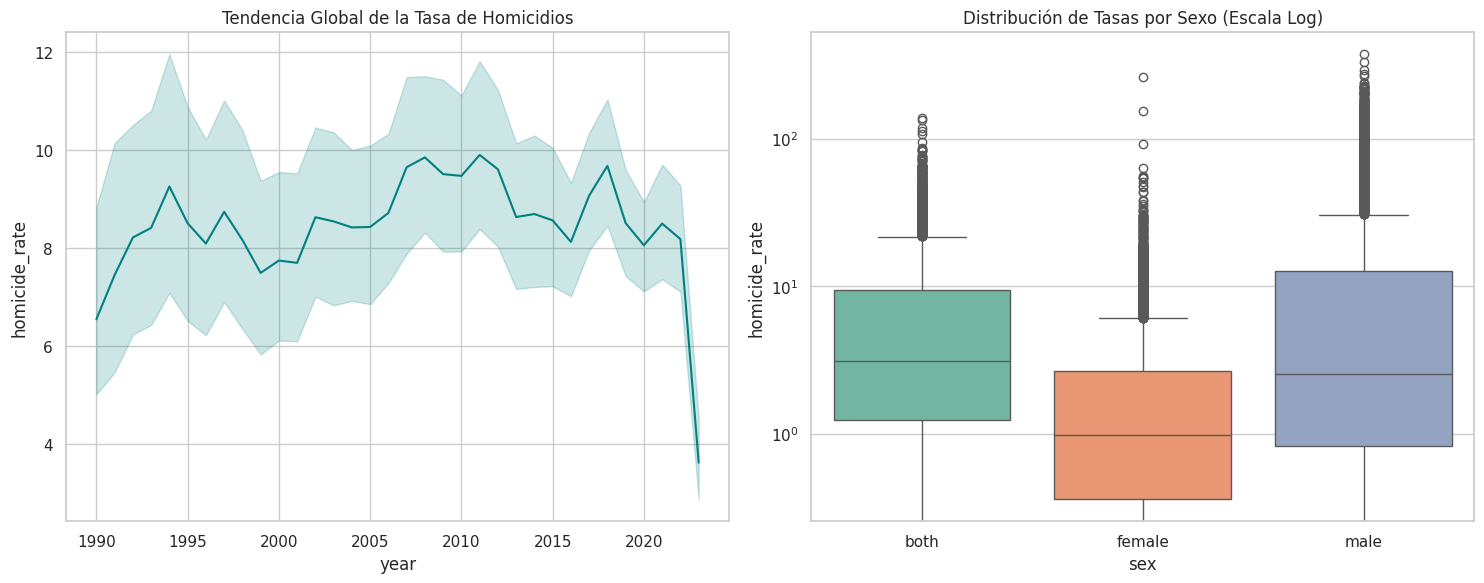

In [ ]:
plt.figure(figsize=(15, 6))

# Gráfico 1: Evolución temporal global
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='year', y='homicide_rate', estimator='mean', color='teal')
plt.title('Tendencia Global de la Tasa de Homicidios')

# Gráfico 2: Comparación por Sexo
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='sex', y='homicide_rate', palette='Set2')
plt.yscale('log') # Usamos escala logarítmica si hay mucha diferencia de valores
plt.title('Distribución de Tasas por Sexo (Escala Log)')

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['iso_code', 'country', 'year', 'sex', 'age_group', 'homicide_rate'], dtype='object')